In [1]:
#Figure 1 Calculation

In [2]:
import numpy as np
import xarray as xr
import os 
import glob

In [3]:
#Reading one year of AR category data
path = "/pscratch/sd/k/kquagra/Side_Jobs/Diya Collab/Categorised_ERA5_WCNA_data/"

file_names =sorted(glob.glob(path + "AR_categorization_2015*.nc"))
#print(file_names)

In [4]:
ds = xr.open_mfdataset(file_names)
AR_event_category = ds['AR_event_category']
print(AR_event_category)

<xarray.DataArray 'AR_event_category' (time: 1460, latitude: 241, longitude: 441)> Size: 155MB
dask.array<concatenate, shape=(1460, 241, 441), dtype=int8, chunksize=(124, 241, 441), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float64 2kB 60.0 59.75 59.5 59.25 ... 0.5 0.25 0.0
  * longitude  (longitude) float64 4kB -160.0 -159.8 -159.5 ... -50.25 -50.0
  * time       (time) datetime64[ns] 12kB 2015-01-01 ... 2015-12-31T18:00:00
Attributes:
    units:          1
    long_name:      AR Event Categories
    standard_name:  AR_event_category


In [5]:
#Reading co occurence weather phenomena data
coocurrence_path = "/pscratch/sd/d/dkamnani/Results_data/training_label_2015.nc"
ds_co = xr.open_mfdataset(coocurrence_path)
print(ds_co)

<xarray.Dataset> Size: 1GB
Dimensions:          (time: 1460, longitude: 1440, latitude: 481)
Coordinates:
  * time             (time) datetime64[ns] 12kB 2015-01-01 ... 2015-12-31T18:...
  * longitude        (longitude) float64 12kB 0.0 0.25 0.5 ... 359.2 359.5 359.8
  * latitude         (latitude) float64 4kB 60.0 59.75 59.5 ... -59.75 -60.0
Data variables:
    feat_comb_label  (time, latitude, longitude) int8 1GB dask.array<chunksize=(1460, 481, 1440), meta=np.ndarray>


In [6]:
#Extracting the variable and then matching lat and lon
ds_co = ds_co['feat_comb_label']
#Matching array dimension
ds_co = ds_co.sel(latitude=slice(60, 0))
ds_co = ds_co.assign_coords(
    longitude=(((ds_co.longitude + 180) % 360) - 180)
)

# 2. Sort longitudes (important after reassignment to avoid disordered coords)
ds_co = ds_co.sortby('longitude')

# 3. Select the desired longitude range
ds_co = ds_co.sel(longitude=slice(-160, -50))

In [7]:
#Reading AR mask data 
#Teca data 
teca_path = "/global/cfs/cdirs/m4374/catalogues/raw_catalogue_files/observations/teca_era5/ERA5_BARD_AR.2015*.nc4"
teca_data = xr.open_mfdataset(teca_path)
teca_data = teca_data["ar_binary_tag"]
print(teca_data)

<xarray.DataArray 'ar_binary_tag' (time: 8760, latitude: 721, longitude: 1440)> Size: 9GB
dask.array<concatenate, shape=(8760, 721, 1440), dtype=int8, chunksize=(744, 721, 1440), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 70kB 2015-01-01 ... 2015-12-31T23:00:00
  * latitude   (latitude) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
Attributes:
    description:  binary indicator of atmospheric river
    long_name:    binary indicator of atmospheric river
    note:         derived by thresholding ar_probability >= 0.666667
    scheme:       TECA_BARD
    units:        unitless
    version:      1.0


In [8]:
teca_data = teca_data.sel(latitude=slice(0, 60))
teca_data = teca_data.sortby('latitude', ascending = False)

teca_data = teca_data.assign_coords(longitude=(((teca_data.longitude + 180) % 360) - 180))
# 2. Sort longitudes (important after reassignment to avoid disordered coords)
teca_data = teca_data.sortby('longitude')

# 3. Select the desired longitude range
teca_data = teca_data.sel(longitude=slice(-160, -50))
print(teca_data)

<xarray.DataArray 'ar_binary_tag' (time: 8760, latitude: 241, longitude: 441)> Size: 931MB
dask.array<getitem, shape=(8760, 241, 441), dtype=int8, chunksize=(744, 241, 441), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 70kB 2015-01-01 ... 2015-12-31T23:00:00
  * latitude   (latitude) float64 2kB 60.0 59.75 59.5 59.25 ... 0.5 0.25 0.0
  * longitude  (longitude) float64 4kB -160.0 -159.8 -159.5 ... -50.25 -50.0
Attributes:
    description:  binary indicator of atmospheric river
    long_name:    binary indicator of atmospheric river
    note:         derived by thresholding ar_probability >= 0.666667
    scheme:       TECA_BARD
    units:        unitless
    version:      1.0


In [9]:
print(teca_data)

<xarray.DataArray 'ar_binary_tag' (time: 8760, latitude: 241, longitude: 441)> Size: 931MB
dask.array<getitem, shape=(8760, 241, 441), dtype=int8, chunksize=(744, 241, 441), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 70kB 2015-01-01 ... 2015-12-31T23:00:00
  * latitude   (latitude) float64 2kB 60.0 59.75 59.5 59.25 ... 0.5 0.25 0.0
  * longitude  (longitude) float64 4kB -160.0 -159.8 -159.5 ... -50.25 -50.0
Attributes:
    description:  binary indicator of atmospheric river
    long_name:    binary indicator of atmospheric river
    note:         derived by thresholding ar_probability >= 0.666667
    scheme:       TECA_BARD
    units:        unitless
    version:      1.0


## AR Event for LPS

In [10]:
# Define the target date
target_time = np.datetime64('2015-06-15T18:00:00')
print(target_time)

# Select data for the specified time
teca_at_time = teca_data.sel(time= teca_data.time == target_time)
print(teca_at_time)

2015-06-15T18:00:00
<xarray.DataArray 'ar_binary_tag' (time: 1, latitude: 241, longitude: 441)> Size: 106kB
dask.array<getitem, shape=(1, 241, 441), dtype=int8, chunksize=(1, 241, 441), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 8B 2015-06-15T18:00:00
  * latitude   (latitude) float64 2kB 60.0 59.75 59.5 59.25 ... 0.5 0.25 0.0
  * longitude  (longitude) float64 4kB -160.0 -159.8 -159.5 ... -50.25 -50.0
Attributes:
    description:  binary indicator of atmospheric river
    long_name:    binary indicator of atmospheric river
    note:         derived by thresholding ar_probability >= 0.666667
    scheme:       TECA_BARD
    units:        unitless
    version:      1.0


In [11]:
#
example_feat = ds_co.where((teca_at_time ==1) & (AR_event_category.longitude <= -65))
print(example_feat) 


<xarray.DataArray 'feat_comb_label' (time: 1, latitude: 241, longitude: 441)> Size: 425kB
dask.array<where, shape=(1, 241, 441), dtype=float32, chunksize=(1, 241, 441), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 8B 2015-06-15T18:00:00
  * latitude   (latitude) float64 2kB 60.0 59.75 59.5 59.25 ... 0.5 0.25 0.0
  * longitude  (longitude) float64 4kB -160.0 -159.8 -159.5 ... -50.25 -50.0


In [12]:
example_teca = AR_event_category.where(
    (teca_at_time == 1) & (AR_event_category.longitude <= -65)
)
print(example_teca)

<xarray.DataArray 'AR_event_category' (time: 1, latitude: 241, longitude: 441)> Size: 425kB
dask.array<where, shape=(1, 241, 441), dtype=float32, chunksize=(1, 241, 441), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float64 2kB 60.0 59.75 59.5 59.25 ... 0.5 0.25 0.0
  * longitude  (longitude) float64 4kB -160.0 -159.8 -159.5 ... -50.25 -50.0
  * time       (time) datetime64[ns] 8B 2015-06-15T18:00:00
Attributes:
    units:          1
    long_name:      AR Event Categories
    standard_name:  AR_event_category


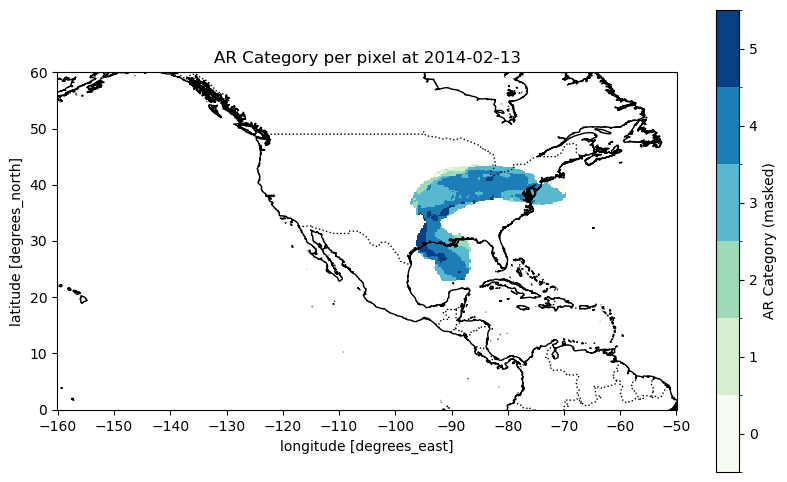

In [14]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm

# Extract your data (e.g., 66th time index)
data = example_teca

# Determine max integer category value in the data (including 0)
max_cat = int(np.nanmax(data.values))

# Create an array of all categories from 0 to max_cat inclusive
categories = np.arange(0, max_cat + 1)

# Number of categories
n_cats = len(categories)

# Use base colormap and sample n_cats colors evenly
base_cmap = plt.get_cmap('GnBu')
colors = base_cmap(np.linspace(0, 1, n_cats))
cmap = ListedColormap(colors)

# Define boundaries that center colors on integers from 0 to max_cat
bounds = np.arange(-0.5, max_cat + 1.5, 1)  # e.g. -0.5,0.5,1.5,...,max_cat+0.5
norm = BoundaryNorm(bounds, ncolors=cmap.N, clip=True)

plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

im = data.plot(
    ax=ax,
    cmap=cmap,
    norm=norm,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={
        'label': 'AR Category (masked)',
        'ticks': categories,           # Show ticks for all integer categories
        'spacing': 'proportional'      # ensures ticks are spaced evenly
    }
)

# Add coastlines, borders, and state lines
ax.coastlines(resolution='10m', linewidth=1)
ax.add_feature(cfeature.BORDERS, linestyle=':')
#ax.add_feature(cfeature.STATES, linestyle='--', edgecolor='gray')

# Set lat/lon ticks (adjust intervals as needed)
ax.set_xticks(np.arange(-160, -40, 10), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(0, 70, 10), crs=ccrs.PlateCarree())

# Add gridlines and labels
#ax.gridlines(draw_labels=False, dms=False, x_inline=False, y_inline=False)

ax.set_title("AR Category per pixel at 2014-02-13")
plt.show()


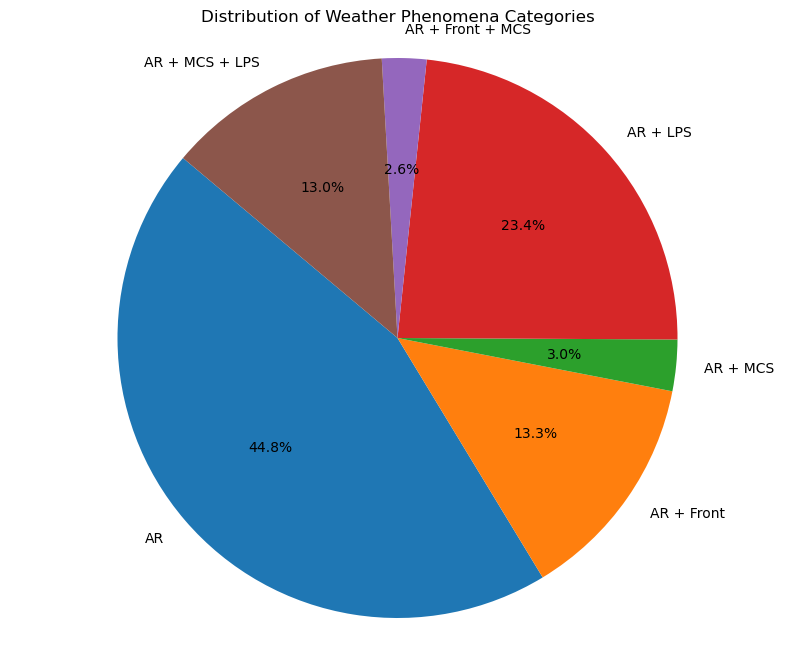

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Your label index mapping
label_index = {
    1: 'AR',
    2: 'Front',
    3: 'MCS',
    4: 'LPS',
    5: 'AR + Front',
    6: 'AR + MCS',
    7: 'AR + LPS',
    8: 'Front + MCS',
    9: 'Front + LPS',
    10: 'MCS + LPS',
    11: 'AR + Front + MCS',
    12: 'AR + Front + LPS',
    13: 'AR + MCS + LPS',
    14: 'Front + MCS + LPS',
    15: 'All'
}

# Flatten the data and remove NaNs
data = example_feat.values.flatten()
data = data[~np.isnan(data)]

# Remove zeros (no phenomena)
data = data[data != 0]

# Get unique categories and their counts
unique, counts = np.unique(data, return_counts=True)

# Compute percentages
percentages = counts / counts.sum() * 100

# Map unique values to labels
labels = [label_index[int(cat)] for cat in unique]

# Create the pie chart
plt.figure(figsize=(10, 8))
plt.pie(percentages, labels=labels, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Weather Phenomena Categories')
plt.axis('equal')  # Equal aspect ratio ensures the pie chart is circular
plt.show()

In [16]:
example_feat.to_netcdf("example_feat_LPS.nc")
example_teca.to_netcdf("example_teca_LPS.nc")

## AR Event for Front

In [17]:
# Define the target date
target_time = np.datetime64('2015-01-17T12:00:00')
print(target_time)

# Select data for the specified time
teca_at_time = teca_data.sel(time= teca_data.time == target_time)
print(teca_at_time)

2015-01-17T12:00:00
<xarray.DataArray 'ar_binary_tag' (time: 1, latitude: 241, longitude: 441)> Size: 106kB
dask.array<getitem, shape=(1, 241, 441), dtype=int8, chunksize=(1, 241, 441), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 8B 2015-01-17T12:00:00
  * latitude   (latitude) float64 2kB 60.0 59.75 59.5 59.25 ... 0.5 0.25 0.0
  * longitude  (longitude) float64 4kB -160.0 -159.8 -159.5 ... -50.25 -50.0
Attributes:
    description:  binary indicator of atmospheric river
    long_name:    binary indicator of atmospheric river
    note:         derived by thresholding ar_probability >= 0.666667
    scheme:       TECA_BARD
    units:        unitless
    version:      1.0


In [18]:
example_feat = ds_co.where((teca_at_time ==1) & (AR_event_category.longitude <= -65))
print(example_feat) 

<xarray.DataArray 'feat_comb_label' (time: 1, latitude: 241, longitude: 441)> Size: 425kB
dask.array<where, shape=(1, 241, 441), dtype=float32, chunksize=(1, 241, 441), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 8B 2015-01-17T12:00:00
  * latitude   (latitude) float64 2kB 60.0 59.75 59.5 59.25 ... 0.5 0.25 0.0
  * longitude  (longitude) float64 4kB -160.0 -159.8 -159.5 ... -50.25 -50.0


In [19]:
example_teca = AR_event_category.where(
    (teca_at_time == 1) & (AR_event_category.longitude <= -65)
)
print(example_teca)

<xarray.DataArray 'AR_event_category' (time: 1, latitude: 241, longitude: 441)> Size: 425kB
dask.array<where, shape=(1, 241, 441), dtype=float32, chunksize=(1, 241, 441), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float64 2kB 60.0 59.75 59.5 59.25 ... 0.5 0.25 0.0
  * longitude  (longitude) float64 4kB -160.0 -159.8 -159.5 ... -50.25 -50.0
  * time       (time) datetime64[ns] 8B 2015-01-17T12:00:00
Attributes:
    units:          1
    long_name:      AR Event Categories
    standard_name:  AR_event_category


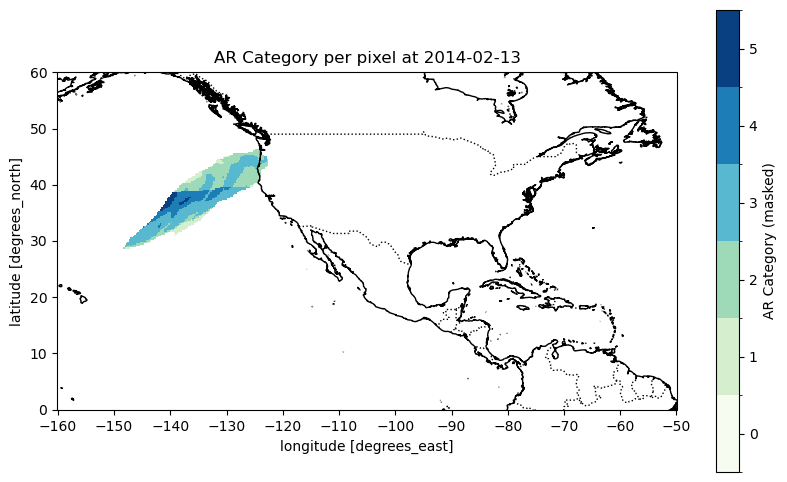

In [20]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm

# Extract your data (e.g., 66th time index)
data = example_teca

# Determine max integer category value in the data (including 0)
max_cat = int(np.nanmax(data.values))

# Create an array of all categories from 0 to max_cat inclusive
categories = np.arange(0, max_cat + 1)

# Number of categories
n_cats = len(categories)

# Use base colormap and sample n_cats colors evenly
base_cmap = plt.get_cmap('GnBu')
colors = base_cmap(np.linspace(0, 1, n_cats))
cmap = ListedColormap(colors)

# Define boundaries that center colors on integers from 0 to max_cat
bounds = np.arange(-0.5, max_cat + 1.5, 1)  # e.g. -0.5,0.5,1.5,...,max_cat+0.5
norm = BoundaryNorm(bounds, ncolors=cmap.N, clip=True)

plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

im = data.plot(
    ax=ax,
    cmap=cmap,
    norm=norm,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={
        'label': 'AR Category (masked)',
        'ticks': categories,           # Show ticks for all integer categories
        'spacing': 'proportional'      # ensures ticks are spaced evenly
    }
)

# Add coastlines, borders, and state lines
ax.coastlines(resolution='10m', linewidth=1)
ax.add_feature(cfeature.BORDERS, linestyle=':')
#ax.add_feature(cfeature.STATES, linestyle='--', edgecolor='gray')

# Set lat/lon ticks (adjust intervals as needed)
ax.set_xticks(np.arange(-160, -40, 10), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(0, 70, 10), crs=ccrs.PlateCarree())

# Add gridlines and labels
#ax.gridlines(draw_labels=False, dms=False, x_inline=False, y_inline=False)

ax.set_title("AR Category per pixel at 2014-02-13")
plt.show()


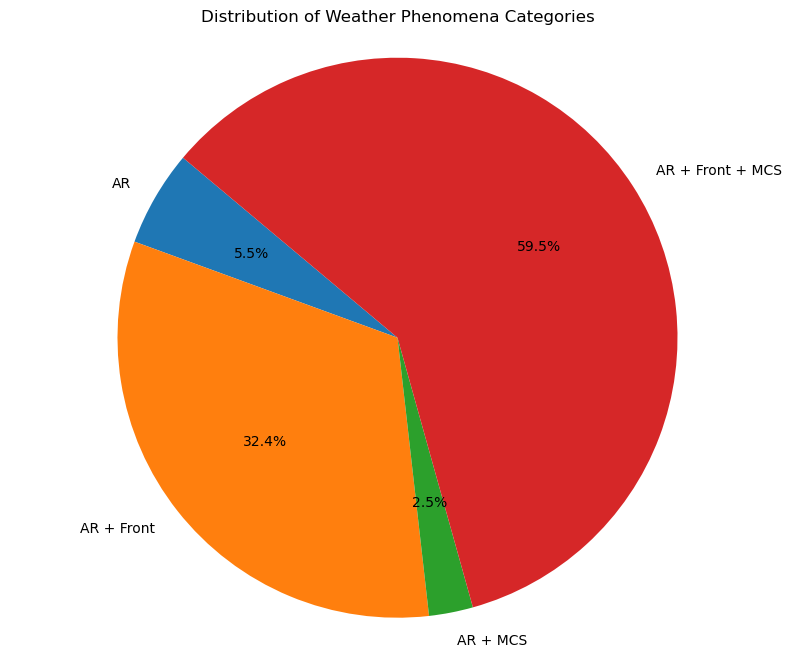

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Your label index mapping
label_index = {
    1: 'AR',
    2: 'Front',
    3: 'MCS',
    4: 'LPS',
    5: 'AR + Front',
    6: 'AR + MCS',
    7: 'AR + LPS',
    8: 'Front + MCS',
    9: 'Front + LPS',
    10: 'MCS + LPS',
    11: 'AR + Front + MCS',
    12: 'AR + Front + LPS',
    13: 'AR + MCS + LPS',
    14: 'Front + MCS + LPS',
    15: 'All'
}

# Flatten the data and remove NaNs
data = example_feat.values.flatten()
data = data[~np.isnan(data)]

# Remove zeros (no phenomena)
data = data[data != 0]

# Get unique categories and their counts
unique, counts = np.unique(data, return_counts=True)

# Compute percentages
percentages = counts / counts.sum() * 100

# Map unique values to labels
labels = [label_index[int(cat)] for cat in unique]

# Create the pie chart
plt.figure(figsize=(10, 8))
plt.pie(percentages, labels=labels, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Weather Phenomena Categories')
plt.axis('equal')  # Equal aspect ratio ensures the pie chart is circular
plt.show()

In [22]:
example_feat.to_netcdf("example_feat_Front.nc")
example_teca.to_netcdf("example_teca_Front.nc")